In [6]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def f1_from_nonzero(A_true, A_est):
    A_true_nz = (A_true != 0)
    A_est_nz  = (A_est  != 0)

    TP = np.sum(A_true_nz & A_est_nz)
    FP = np.sum(~A_true_nz & A_est_nz)
    FN = np.sum(A_true_nz & ~A_est_nz)

    precision = TP / (TP + FP + 1e-12)
    recall    = TP / (TP + FN + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)

    return TP, FP, FN, precision, recall, f1

### Grid Search

In [3]:
folder = "d4"  

W1_thres = 0.3
W2_thres = 0.2

# Track best files
best_f1_W1 = -1.0
best_f1_W1_file = None

best_f1_W2 = -1.0
best_f1_W2_file = None

best_avg_f1 = -1.0
best_avg_f1_file = None

for filename in os.listdir(folder):

    file_path = os.path.join(folder, filename)
    print("Processing:", file_path)

    with open(file_path, "r") as f:
        data = json.load(f)

    # --- truth ---
    W_truth = np.array(data["W_truth"])
    Sigma_truth = np.array(data["Sigma_truth"])  # assumes this key exists

    W_truth[np.abs(W_truth) < W1_thres] = 0
    Sigma_truth[np.abs(Sigma_truth) < W2_thres] = 0

    # --- pick run_id == 0 ---
    W_est = None
    Sigma_est = None
    chosen_run = None

    for run in data["random_runs"]:
        if run["run_id"] == 0:
            chosen_run = run
            W_est = np.array(run["W_est_random"])
            Sigma_est = np.array(run["Sigma_est_random"])
            break

    if W_est is None or Sigma_est is None:
        print(f"  Skipping {filename}: run_id == 0 not found.")
        continue

    # --- threshold estimates ---
    W_est[np.abs(W_est) < W1_thres] = 0
    Sigma_est[np.abs(Sigma_est) < W2_thres] = 0

    # --- F1 for W ---
    TP_W1, FP_W1, FN_W1, precision_W1, recall_W1, f1_W1 = f1_from_nonzero(W_truth, W_est)

    # --- F1 for Sigma (strictly lower-triangular) ---
    TP_W2, FP_W2, FN_W2, precision_W2, recall_W2, f1_W2 = f1_from_nonzero(
        np.tril(Sigma_truth, k=-1),
        np.tril(Sigma_est,   k=-1),
    )

    # --- save metrics into JSON ---
    data["f1_W1"] = round(f1_W1, 4)
    data["f1_W2"] = round(f1_W2, 4)
    # print("TP_W1", TP_W1)
    data["TP_W1"] = TP_W1.item()
    data["FP_W1"] = FP_W1.item()
    data["FN_W1"] = FN_W1.item()

    data["TP_W2"] = TP_W2.item()
    data["FP_W2"] = FP_W2.item()
    data["FN_W2"] = FN_W2.item()

    with open(file_path, "w") as f:
        json.dump(data, f, indent=2)

    # --- update best trackers ---
    avg_f1 = 0.5 * (f1_W1 + f1_W2)

    if f1_W1 > best_f1_W1:
        best_f1_W1 = f1_W1
        best_f1_W1_file = filename

    if f1_W2 > best_f1_W2:
        best_f1_W2 = f1_W2
        best_f1_W2_file = filename

    if avg_f1 > best_avg_f1:
        best_avg_f1 = avg_f1
        best_avg_f1_file = filename

# After the loop, print results
print("\n=== Best files ===")
print(f"Best f1_W1: {best_f1_W1:.4f} in file {best_f1_W1_file}")
print(f"Best f1_W2: {best_f1_W2:.4f} in file {best_f1_W2_file}")
print(f"Best average (f1_W1 + f1_W2)/2: {best_avg_f1:.4f} in file {best_avg_f1_file}")

Processing: d4/result_d4_admg20_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg19_seed6_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg13_seed7_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg23_seed9_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg13_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg19_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg2_seed1_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg19_seed0_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg2_seed8_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg2_seed0_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg12_seed9_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg20_seed1_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Process

In [4]:
folder = "d4"  
scores = []

for filename in os.listdir(folder):
    file_path = os.path.join(folder, filename)
    print("Processing:", file_path)
    with open(file_path, "r") as f:
        data = json.load(f)
        f1_W1 = data["f1_W1"]
        f1_W2 = data["f1_W2"]
        avg_f1 = 0.5 * (f1_W1 + f1_W2)

    scores.append((filename, f1_W1, f1_W2, avg_f1))

best_f1_W1 = max(s[1] for s in scores)
best_f1_W2 = max(s[2] for s in scores)
best_avg_f1 = max(s[3] for s in scores)

best_f1_W1_files = [f for f, s1, _, _ in scores if s1 == best_f1_W1]
best_f1_W2_files = [f for f, _, s2, _ in scores if s2 == best_f1_W2]
best_avg_f1_files = [f for f, _, _, a in scores if a == best_avg_f1]




Processing: d4/result_d4_admg20_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg19_seed6_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg13_seed7_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg23_seed9_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg13_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg19_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg2_seed1_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg19_seed0_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg2_seed8_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg2_seed0_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg12_seed9_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Processing: d4/result_d4_admg20_seed1_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
Process

In [5]:
print(f"Best f1_W1: {best_f1_W1:.4f} in files:\n" +
      "\n".join(best_f1_W1_files))

Best f1_W1: 1.0000 in files:
result_d4_admg23_seed9_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg19_seed0_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg2_seed8_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg2_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg17_seed2_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg12_seed8_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg7_seed2_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg23_seed1_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg7_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg13_seed9_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg7_seed5_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg12_seed3_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg23_seed8_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg19_seed1_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg7_seed3_la

In [6]:
print(f"Best f1_W2: {best_f1_W2:.4f} in files:\n" +
      "\n".join(best_f1_W2_files))

Best f1_W2: 1.0000 in files:
result_d4_admg20_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg23_seed9_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg19_seed0_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg2_seed8_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg20_seed1_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg2_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg17_seed2_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg12_seed8_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg7_seed2_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg23_seed1_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg3_seed9_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg7_seed4_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg13_seed9_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg19_seed2_lambda0.001_lambda_corr0.1_lambda_nl8.0.json
result_d4_admg7_seed5_la

In [19]:
print(f"Best avg_f1: {best_avg_f1:.4f} in files:\n" +
      "\n".join(best_avg_f1_files))

Best avg_f1: 0.7333 in files:
result_d4_admg4_seed13_lambda0.1_lambda_corr0.001_lambda_nl8.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.001_lambda_nl1.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.1_lambda_nl1.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.1_lambda_nl4.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.01_lambda_nl4.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.001_lambda_nl4.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.001_lambda_nl12.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.01_lambda_nl8.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.01_lambda_nl12.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.1_lambda_nl12.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.01_lambda_nl1.0.json
result_d4_admg4_seed13_lambda0.1_lambda_corr0.1_lambda_nl8.0.json


In [23]:
folder = "result_d4_s4(new_reg)"  
filename = f"result_d4_admg4_seed13_lambda0.1_lambda_corr0.1_lambda_nl8.0.json" 
file_path = os.path.join(folder, filename)
with open(file_path, "r") as f:
        data = json.load(f)

for run in data["random_runs"]:
        if run["run_id"] == 0:
                chosen_run = run
                W_est = np.array(run["W_est_random"])
                Sigma_est = np.array(run["Sigma_est_random"])
                break
f1_W1 = data["f1_W1"]
f1_W2 = data["f1_W2"]
print("f1_W1: ", f1_W1)
print("f1_W2: ", f1_W2)
print("W_est: ", W_est)
print("Sigma_est: ", Sigma_est)

f1_W1:  0.8
f1_W2:  0.6667
W_est:  [[9.80039288e-11 6.23664007e-05 2.05851893e-04 1.08608430e-04]
 [6.33598465e-01 3.56612880e-11 3.90264849e-04 2.90933635e+00]
 [1.36246731e-01 6.50532301e-05 1.69359540e-11 1.55951067e+00]
 [7.18581070e-04 8.50695378e-05 1.86068836e-04 2.98457578e-10]]
Sigma_est:  [[ 5.14223049e-01 -8.80462703e-06 -2.40243870e-06  6.25228146e-01]
 [-8.80462703e-06  9.94097613e-01 -2.66511685e-02  3.60250644e-07]
 [-2.40243870e-06 -2.66511685e-02  1.02418292e+00 -2.27895064e-06]
 [ 6.25228146e-01  3.60250644e-07 -2.27895064e-06  1.01952580e+00]]


## Overall f1 

In [75]:
def admg_to_adjacency(admg: dict):
    """
    Convert ADMG dict to directed and bidirected adjacency matrices.

    Returns:
        A_dir   : [d, d] numpy array, A_dir[i, j] = 1 if i -> j
        A_bidir : [d, d] numpy array, A_bidir[i, j] = 1 if i <-> j
    """
    nodes = sorted(int(k) for k in admg.keys())
    d = len(nodes)

    A_dir = np.zeros((d, d), dtype=int)
    A_bidir = np.zeros((d, d), dtype=int)

    for v_str, info in admg.items():
        v = int(v_str)

        # directed edges: u -> v
        for u in info.get("parents", []):
            A_dir[u, v] = 1

        # bidirected edges: u <-> v
        for u in info.get("spouses", []):
            A_bidir[u, v] = 1
            A_bidir[v, u] = 1  # ensure symmetry

    return A_dir, A_bidir

def prf(TP, FP, FN):
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return precision, recall, f1

In [76]:
g = "ancestral"
m = "func"
result_dic = {}
folder = {f"d4_{g}_{m}", f"d4_linear_{g}_{m}", f"d4_nonlinear_{g}_{m}", f"d4_fci_{g}_{m}"}  

for f in folder:
    if "nonlinear" in f:
        W1_thres = 0.5
        W2_thres = 0.5
    else:
        W1_thres = 0.3
        W2_thres = 0.2
    TP_tot_W1 = 0
    FP_tot_W1 = 0
    FN_tot_W1 = 0

    TP_tot_W2 = 0
    FP_tot_W2 = 0
    FN_tot_W2 = 0

    run_time_count = 0
    run_time_tot = 0
    tot = 0

    for filename in os.listdir(f):

        file_path = os.path.join(f, filename)
        print("Processing:", file_path)

        with open(file_path, "r") as d:
            data = json.load(d)

        # --- truth ---
        admg = data["admg"]
        W_truth, Sigma_truth = admg_to_adjacency(admg)
        # W_truth = np.array(data["W_truth"])
        # Sigma_truth = np.array(data["Sigma_truth"])  # assumes this key exists

        # W_truth[np.abs(W_truth) < W1_thres] = 0
        # Sigma_truth[np.abs(Sigma_truth) < W2_thres] = 0

        # --- pick run_id == 0 ---
        W_est = None
        Sigma_est = None
        chosen_run = None

        if "nonlinear" in f:
            W_est = np.array(data["directed_adj_final"]) 
            Sigma_est = np.array(data["bidirected_adj_final"])
            run_time = data.get("train_running_time_mean")
            W_est[np.abs(W_est) < W1_thres] = 0
            Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
            
        elif "linear" in f or "fci" in f:
            W_est = np.array(data["A_dir"])
            Sigma_est = np.array(data["A_bidir"])
            run_time = data["run_time_sec"]
       
        else:
            for run in data["random_runs"]:
                if run["run_id"] == 0:
                    chosen_run = run
                    W_est = np.array(run["W_est_random"])
                    Sigma_est = np.array(run["Sigma_est_random"])
                    run_time = run["run_time_sec"]
                    W_est[np.abs(W_est) < W1_thres] = 0
                    Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
                    break

        if W_est is None or Sigma_est is None:
            print(f"  Skipping {filename}: run_id == 0 not found.")
            continue

        # --- F1 for W ---
        TP_W1, FP_W1, FN_W1, precision_W1, recall_W1, f1_W1 = f1_from_nonzero(W_truth, W_est)

        # --- F1 for Sigma (strictly lower-triangular) ---
        TP_W2, FP_W2, FN_W2, precision_W2, recall_W2, f1_W2 = f1_from_nonzero(
            np.tril(Sigma_truth, k=-1),
            np.tril(Sigma_est,   k=-1),
        )

        TP_tot_W1 += TP_W1
        FP_tot_W1 += FP_W1
        FN_tot_W1 += FN_W1

        TP_tot_W2 += TP_W2
        FP_tot_W2 += FP_W2
        FN_tot_W2 += FN_W2

        tot += 1
        if run_time is not None and np.isfinite(run_time):
            run_time_tot += float(run_time)
            run_time_count += 1
        else:
            print(f"  Warning: runtime missing in {filename}")

    precision_W1, recall_W1, f1_W1 = prf(TP_tot_W1, FP_tot_W1, FN_tot_W1)
    precision_W2, recall_W2, f1_W2 = prf(TP_tot_W2, FP_tot_W2, FN_tot_W2)

    run_time_avg = run_time_tot / run_time_count if run_time_count > 0 else 0

    result_dic[f"{f}_precision_W1"]=precision_W1
    result_dic[f"{f}_recall_W1"]=recall_W1
    result_dic[f"{f}_f1_W1"]=f1_W1

    result_dic[f"{f}_precision_W2"]=precision_W2
    result_dic[f"{f}_recall_W2"]=recall_W2
    result_dic[f"{f}_f1_W2"]=f1_W2
    result_dic[f"{f}_run_time"]=run_time_avg
    result_dic[f"{f}_failure_rate"]=1-tot/100

Processing: d4_linear_ancestral_func/result_d4_admg17_seed9_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg12_seed6_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg7_seed4_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg12_seed7_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg17_seed5_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg23_seed6_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg12_seed9_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg13_seed3_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg12_seed1_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg23_seed9_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg7_seed7_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg20_seed3_ffunc_linear.json
Processing: d4_linear_ancestral_func/result_d4_admg13_seed9_ffunc_

In [77]:
result_dic

{'d4_linear_ancestral_func_precision_W1': np.float64(0.48863636363636365),
 'd4_linear_ancestral_func_recall_W1': np.float64(0.45263157894736844),
 'd4_linear_ancestral_func_f1_W1': np.float64(0.4699453551912569),
 'd4_linear_ancestral_func_precision_W2': np.float64(0.5547445255474452),
 'd4_linear_ancestral_func_recall_W2': np.float64(0.4470588235294118),
 'd4_linear_ancestral_func_f1_W2': np.float64(0.49511400651465803),
 'd4_linear_ancestral_func_run_time': 32.32525576040149,
 'd4_linear_ancestral_func_failure_rate': 0.0,
 'd4_ancestral_func_precision_W1': np.float64(0.8141025641025641),
 'd4_ancestral_func_recall_W1': np.float64(0.6684210526315789),
 'd4_ancestral_func_f1_W1': np.float64(0.7341040462427746),
 'd4_ancestral_func_precision_W2': np.float64(0.9395973154362416),
 'd4_ancestral_func_recall_W2': np.float64(0.8235294117647058),
 'd4_ancestral_func_f1_W2': np.float64(0.877742946708464),
 'd4_ancestral_func_run_time': 2915.79834921211,
 'd4_ancestral_func_failure_rate': 0.0,

In [78]:
# folder = {"d8_bowfree_MLP100", "d8_linear_bowfree_MLP100", "d8_nonlinear_bowfree_MLP100", "d8_fci_bowfree_MLP100"}  
folder = {f"d8_{g}_{m}", f"d8_linear_{g}_{m}", f"d8_nonlinear_{g}_{m}", f"d8_fci_{g}_{m}"}   

for f in folder:
    if "nonlinear" in f:
        W1_thres = 0.5
        W2_thres = 0.5
    else:
        W1_thres = 0.3
        W2_thres = 0.2
    TP_tot_W1 = 0
    FP_tot_W1 = 0
    FN_tot_W1 = 0

    TP_tot_W2 = 0
    FP_tot_W2 = 0
    FN_tot_W2 = 0

    run_time_count = 0
    run_time_tot = 0
    tot = 0

    for filename in os.listdir(f):

        file_path = os.path.join(f, filename)
        print("Processing:", file_path)

        with open(file_path, "r") as d:
            data = json.load(d)

        # --- truth ---
        admg = data["admg"]
        W_truth, Sigma_truth = admg_to_adjacency(admg)
        # W_truth = np.array(data["W_truth"])
        # Sigma_truth = np.array(data["Sigma_truth"])  # assumes this key exists

        # W_truth[np.abs(W_truth) < W1_thres] = 0
        # Sigma_truth[np.abs(Sigma_truth) < W2_thres] = 0

        # --- pick run_id == 0 ---
        W_est = None
        Sigma_est = None
        chosen_run = None

        if "nonlinear" in f:
            W_est = np.array(data["directed_adj_final"]) 
            Sigma_est = np.array(data["bidirected_adj_final"])
            run_time = data.get("train_running_time_mean")
            W_est[np.abs(W_est) < W1_thres] = 0
            Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
            
        elif "linear" in f or "fci" in f:
            W_est = np.array(data["A_dir"])
            Sigma_est = np.array(data["A_bidir"])
            run_time = data["run_time_sec"]
       
        else:
            for run in data["random_runs"]:
                if run["run_id"] == 0:
                    chosen_run = run
                    W_est = np.array(run["W_est_random"])
                    Sigma_est = np.array(run["Sigma_est_random"])
                    run_time = run["run_time_sec"]
                    W_est[np.abs(W_est) < W1_thres] = 0
                    Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
                    break

        if W_est is None or Sigma_est is None:
            print(f"  Skipping {filename}: run_id == 0 not found.")
            continue

        # --- F1 for W ---
        TP_W1, FP_W1, FN_W1, precision_W1, recall_W1, f1_W1 = f1_from_nonzero(W_truth, W_est)

        # --- F1 for Sigma (strictly lower-triangular) ---
        TP_W2, FP_W2, FN_W2, precision_W2, recall_W2, f1_W2 = f1_from_nonzero(
            np.tril(Sigma_truth, k=-1),
            np.tril(Sigma_est,   k=-1),
        )

        TP_tot_W1 += TP_W1
        FP_tot_W1 += FP_W1
        FN_tot_W1 += FN_W1

        TP_tot_W2 += TP_W2
        FP_tot_W2 += FP_W2
        FN_tot_W2 += FN_W2

        tot += 1
        if run_time is not None and np.isfinite(run_time):
            run_time_tot += float(run_time)
            run_time_count += 1
        else:
            print(f"  Warning: runtime missing in {filename}")

    precision_W1, recall_W1, f1_W1 = prf(TP_tot_W1, FP_tot_W1, FN_tot_W1)
    precision_W2, recall_W2, f1_W2 = prf(TP_tot_W2, FP_tot_W2, FN_tot_W2)

    run_time_avg = run_time_tot / run_time_count if run_time_count > 0 else 0

    result_dic[f"{f}_precision_W1"]=precision_W1
    result_dic[f"{f}_recall_W1"]=recall_W1
    result_dic[f"{f}_f1_W1"]=f1_W1

    result_dic[f"{f}_precision_W2"]=precision_W2
    result_dic[f"{f}_recall_W2"]=recall_W2
    result_dic[f"{f}_f1_W2"]=f1_W2
    result_dic[f"{f}_run_time"]=run_time_avg
    result_dic[f"{f}_failure_rate"]=1-tot/100

       

Processing: d8_nonlinear_ancestral_func/result_d8_admg14_seed7_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg10_seed9_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg8_seed1_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg9_seed7_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg10_seed0_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg10_seed1_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg9_seed6_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg0_seed2_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg8_seed6_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg9_seed0_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg9_seed5_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg8_seed3_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_d8_admg9_seed9_ffunc.json
Processing: d8_nonlinear_ancestral_func/result_

In [79]:
result_dic

{'d4_linear_ancestral_func_precision_W1': np.float64(0.48863636363636365),
 'd4_linear_ancestral_func_recall_W1': np.float64(0.45263157894736844),
 'd4_linear_ancestral_func_f1_W1': np.float64(0.4699453551912569),
 'd4_linear_ancestral_func_precision_W2': np.float64(0.5547445255474452),
 'd4_linear_ancestral_func_recall_W2': np.float64(0.4470588235294118),
 'd4_linear_ancestral_func_f1_W2': np.float64(0.49511400651465803),
 'd4_linear_ancestral_func_run_time': 32.32525576040149,
 'd4_linear_ancestral_func_failure_rate': 0.0,
 'd4_ancestral_func_precision_W1': np.float64(0.8141025641025641),
 'd4_ancestral_func_recall_W1': np.float64(0.6684210526315789),
 'd4_ancestral_func_f1_W1': np.float64(0.7341040462427746),
 'd4_ancestral_func_precision_W2': np.float64(0.9395973154362416),
 'd4_ancestral_func_recall_W2': np.float64(0.8235294117647058),
 'd4_ancestral_func_f1_W2': np.float64(0.877742946708464),
 'd4_ancestral_func_run_time': 2915.79834921211,
 'd4_ancestral_func_failure_rate': 0.0,

In [80]:
folder = {f"d12_{g}_{m}", f"d12_linear_{g}_{m}", f"d12_nonlinear_{g}_{m}", f"d12_fci_{g}_{m}"}  

for f in folder:
    if "nonlinear" in f:
        W1_thres = 0.5
        W2_thres = 0.5
    else:
        W1_thres = 0.3
        W2_thres = 0.2
    TP_tot_W1 = 0
    FP_tot_W1 = 0
    FN_tot_W1 = 0

    TP_tot_W2 = 0
    FP_tot_W2 = 0
    FN_tot_W2 = 0

    run_time_count = 0
    run_time_tot = 0
    tot = 0

    for filename in os.listdir(f):

        file_path = os.path.join(f, filename)
        print("Processing:", file_path)

        with open(file_path, "r") as d:
            data = json.load(d)

        # --- truth ---
        admg = data["admg"]
        W_truth, Sigma_truth = admg_to_adjacency(admg)
        # W_truth = np.array(data["W_truth"])
        # Sigma_truth = np.array(data["Sigma_truth"])  # assumes this key exists

        # W_truth[np.abs(W_truth) < W1_thres] = 0
        # Sigma_truth[np.abs(Sigma_truth) < W2_thres] = 0

        # --- pick run_id == 0 ---
        W_est = None
        Sigma_est = None
        chosen_run = None

        if "nonlinear" in f:
            W_est = np.array(data["directed_adj_final"]) 
            Sigma_est = np.array(data["bidirected_adj_final"])
            run_time = data.get("train_running_time_mean")
            W_est[np.abs(W_est) < W1_thres] = 0
            Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
            
        elif "linear" in f or "fci" in f:
            W_est = np.array(data["A_dir"])
            Sigma_est = np.array(data["A_bidir"])
            run_time = data["run_time_sec"]
       
        else:
            for run in data["random_runs"]:
                if run["run_id"] == 0:
                    chosen_run = run
                    W_est = np.array(run["W_est_random"])
                    Sigma_est = np.array(run["Sigma_est_random"])
                    run_time = run["run_time_sec"]
                    W_est[np.abs(W_est) < W1_thres] = 0
                    Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
                    break

        if W_est is None or Sigma_est is None:
            print(f"  Skipping {filename}: run_id == 0 not found.")
            continue

        # --- F1 for W ---
        TP_W1, FP_W1, FN_W1, precision_W1, recall_W1, f1_W1 = f1_from_nonzero(W_truth, W_est)

        # --- F1 for Sigma (strictly lower-triangular) ---
        TP_W2, FP_W2, FN_W2, precision_W2, recall_W2, f1_W2 = f1_from_nonzero(
            np.tril(Sigma_truth, k=-1),
            np.tril(Sigma_est,   k=-1),
        )

        TP_tot_W1 += TP_W1
        FP_tot_W1 += FP_W1
        FN_tot_W1 += FN_W1

        TP_tot_W2 += TP_W2
        FP_tot_W2 += FP_W2
        FN_tot_W2 += FN_W2

        tot += 1
        if run_time is not None and np.isfinite(run_time):
            run_time_tot += float(run_time)
            run_time_count += 1
        else:
            print(f"  Warning: runtime missing in {filename}")

    precision_W1, recall_W1, f1_W1 = prf(TP_tot_W1, FP_tot_W1, FN_tot_W1)
    precision_W2, recall_W2, f1_W2 = prf(TP_tot_W2, FP_tot_W2, FN_tot_W2)

    run_time_avg = run_time_tot / run_time_count if run_time_count > 0 else 0

    result_dic[f"{f}_precision_W1"]=precision_W1
    result_dic[f"{f}_recall_W1"]=recall_W1
    result_dic[f"{f}_f1_W1"]=f1_W1

    result_dic[f"{f}_precision_W2"]=precision_W2
    result_dic[f"{f}_recall_W2"]=recall_W2
    result_dic[f"{f}_f1_W2"]=f1_W2
    result_dic[f"{f}_run_time"]=run_time_avg
    result_dic[f"{f}_failure_rate"]=1-tot/100

Processing: d12_fci_ancestral_func/result_d12_admg8_seed0_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg19_seed6_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg10_seed4_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg5_seed4_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg2_seed0_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg6_seed3_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg10_seed6_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg19_seed3_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg9_seed8_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg20_seed6_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg5_seed2_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg9_seed1_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12_admg19_seed8_ffunc_fci.json
Processing: d12_fci_ancestral_func/result_d12

In [81]:
methods = {}
for k, v in result_dic.items():
    parts = k.split("_")
    if "_f1_" in k:
        method = "_".join(parts[:-2])   # e.g. d4_linear_MLP100
        metric = parts[-1]              # W1 or W2
        methods.setdefault(method, {})[metric] = float(v)

    # parts = k.split("_")
    # # examples:
    # # result_d4_geomean_f1_W1
    # # result_d4_f1_W2

    # method = "_".join(parts[:-2])   # result_d4_geomean
    # metric = parts[-1]              # W1 or W2

    # methods.setdefault(method, {})[metric] = float(v)

    elif k.endswith("_run_time"):
        method = "_".join(parts[:-2])   # remove "run_time"
        methods.setdefault(method, {})["run_time"] = float(v)

    elif k.endswith("_failure_rate"):
        method = "_".join(parts[:-2])   # remove "failure_rate"
        methods.setdefault(method, {})["failure_rate"] = float(v)

methods

{'d4_linear_ancestral_func': {'W1': 0.4699453551912569,
  'W2': 0.49511400651465803,
  'run_time': 32.32525576040149,
  'failure_rate': 0.0},
 'd4_ancestral_func': {'W1': 0.7341040462427746,
  'W2': 0.877742946708464,
  'run_time': 2915.79834921211,
  'failure_rate': 0.0},
 'd4_nonlinear_ancestral_func': {'W1': 0.2447058823529412,
  'W2': 0.35714285714285715,
  'run_time': 210.2115916122198,
  'failure_rate': 0.0},
 'd4_fci_ancestral_func': {'W1': 0.0784313725490196,
  'W2': 0.20100502512562812,
  'run_time': 0.22308697387576104,
  'failure_rate': 0.0},
 'd8_nonlinear_ancestral_func': {'W1': 0.3144329896907217,
  'W2': 0.20833333333333331,
  'run_time': 277.56012111915066,
  'failure_rate': 0.69},
 'd8_ancestral_func': {'W1': 0.6956521739130435,
  'W2': 0.8789808917197452,
  'run_time': 7296.600615571514,
  'failure_rate': 0.0},
 'd8_fci_ancestral_func': {'W1': 0.16033755274261605,
  'W2': 0.4555160142348755,
  'run_time': 0.2838169679790735,
  'failure_rate': 0.0},
 'd8_linear_ancestr

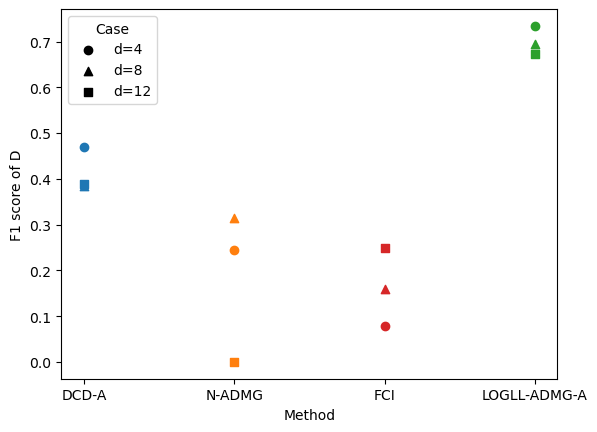

In [82]:
x_labels = ["DCD-A", "N-ADMG", "FCI", "LOGLL-ADMG-A"] if g=="ancestral" else ["DCD-BF", "N-ADMG", "FCI", "LOGLL-ADMG-BF"]
method_pos = {'linear': 0, 'nonlinear': 1, 'fci': 2, 'base': 3}
marker_map = {'d4': 'o', 'd8': '^', 'd12': 's'}
color_map = {
    'linear': 'tab:blue',
    'nonlinear': 'tab:orange',
    'fci': 'tab:red',
    'base': 'tab:green'
}

plt.figure()

for name, vals in methods.items():

    # detect method
    if "_nonlinear" in name:
        method = "nonlinear"
    elif "_linear" in name:
        method = "linear"
    elif "_fci" in name:
        method = "fci"
    else:
        method = "base"

    # detect dimension
    if "d4" in name:
        dim = "d4"
    elif "d8" in name:
        dim = "d8"
    elif "d12" in name:
        dim = "d12"
    else:
        continue

    x = method_pos[method]
    y = vals["W1"]          

    plt.scatter(x, y, marker=marker_map[dim], color=color_map[method])

for dim, marker in marker_map.items():
    label = f"d={dim[1:]}"
    plt.scatter([], [], marker=marker, color='black', label=label)

plt.legend(title="Case")

plt.xticks([0, 1, 2, 3], x_labels)
plt.xlabel("Method")
plt.ylabel("F1 score of D")

plt.show()

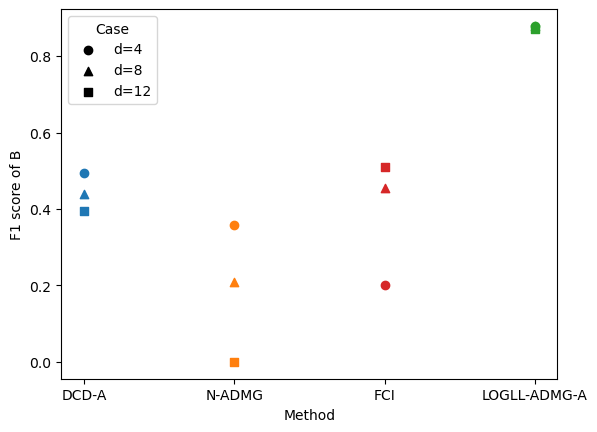

In [84]:
x_labels = ["DCD-A", "N-ADMG", "FCI", "LOGLL-ADMG-A"] if g=="ancestral" else ["DCD-BF", "N-ADMG", "FCI", "LOGLL-ADMG-BF"]
method_pos = {'linear': 0, 'nonlinear': 1, 'fci': 2, 'base': 3}
marker_map = {'d4': 'o', 'd8': '^', 'd12': 's'}
color_map = {
    'linear': 'tab:blue',
    'nonlinear': 'tab:orange',
    'fci': 'tab:red',
    'base': 'tab:green'
}

plt.figure()

for name, vals in methods.items():

    # detect method
    if "_nonlinear" in name:
        method = "nonlinear"
    elif "_linear" in name:
        method = "linear"
    elif "_fci" in name:
        method = "fci"
    else:
        method = "base"

    # detect dimension
    if "d4" in name:
        dim = "d4"
    elif "d8" in name:
        dim = "d8"
    elif "d12" in name:
        dim = "d12"
    else:
        continue

    x = method_pos[method]
    y = vals["W2"]          

    plt.scatter(x, y, marker=marker_map[dim], color=color_map[method])

for dim, marker in marker_map.items():
    label = f"d={dim[1:]}"
    plt.scatter([], [], marker=marker, color='black', label=label)

plt.legend(title="Case")

plt.xticks([0, 1, 2, 3], x_labels)
plt.xlabel("Method")
plt.ylabel("F1 score of B")

plt.show()

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

...

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

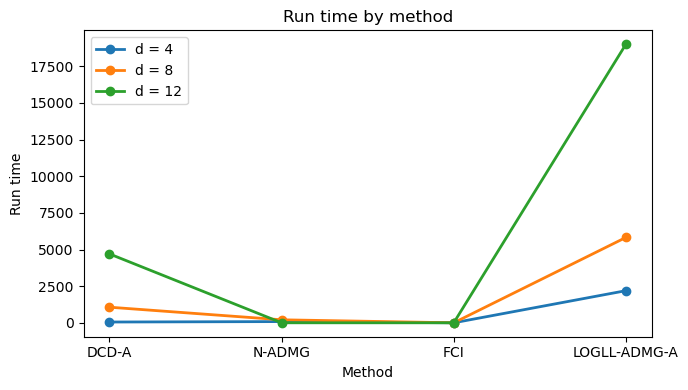

In [71]:
method_order = ["linear", "nonlinear", "fci", "base"]
method_labels = {
    "linear": "DCD-A",
    "nonlinear": "N-ADMG",
    "fci": "FCI",
    "base": "LOGLL-ADMG-A",
}
case_order = ["d4", "d8", "d12"]
case_labels = {"d4": "d = 4", "d8": "d = 8", "d12": "d = 12"}

plot_data = {case: {method: {} for method in method_order} for case in case_order}

for name, vals in methods.items():
    if "_nonlinear" in name:
        method = "nonlinear"
    elif "_linear" in name:
        method = "linear"
    elif "_fci" in name:
        method = "fci"
    else:
        method = "base"

    if "d4" in name:
        case = "d4"
    elif "d8" in name:
        case = "d8"
    elif "d12" in name:
        case = "d12"
    else:
        continue

    plot_data[case][method] = vals

    plt.figure(figsize=(7, 4))

x = np.arange(len(method_order))

for case in case_order:
    y = []
    for method in method_order:
        value = plot_data[case][method].get("run_time", np.nan)
        y.append(value)

    plt.plot(x, y, marker="o", linewidth=2, label=case_labels[case])

plt.xticks(x, [method_labels[m] for m in method_order])
plt.xlabel("Method")
plt.ylabel("Run time")
plt.title("Run time by method")
plt.legend()
plt.tight_layout()
plt.show()

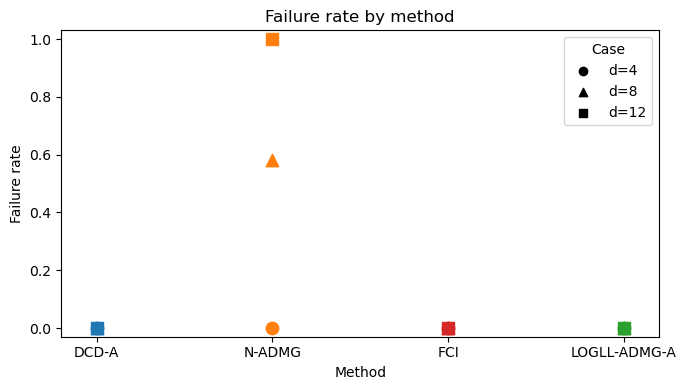

In [72]:
x_labels = ["DCD-A", "N-ADMG", "FCI", "LOGLL-ADMG-A"] if g=="ancestral" else ["DCD-BF", "N-ADMG", "FCI", "LOGLL-ADMG-BF"]
for name, vals in methods.items():
    if "d12" in name and "_nonlinear" in name:
        vals["failure_rate"] = 1.0
        
method_pos = {'linear': 0, 'nonlinear': 1, 'fci': 2, 'base': 3}
marker_map = {'d4': 'o', 'd8': '^', 'd12': 's'}
color_map = {
    'linear': 'tab:blue',
    'nonlinear': 'tab:orange',
    'fci': 'tab:red',
    'base': 'tab:green'
}

fig, ax = plt.subplots(figsize=(7, 4))

for name, vals in methods.items():

    if "_nonlinear" in name:
        method = "nonlinear"
    elif "_linear" in name:
        method = "linear"
    elif "_fci" in name:
        method = "fci"
    else:
        method = "base"

    if "d4" in name:
        dim = "d4"
    elif "d8" in name:
        dim = "d8"
    elif "d12" in name:
        dim = "d12"
    else:
        continue

    if "failure_rate" not in vals:
        continue  # skip methods without failure_rate

    x = method_pos[method]
    y = vals["failure_rate"]

    plt.scatter(x, y, marker=marker_map[dim], color=color_map[method], s=80)

# legend for case (marker shape)
for dim, marker in marker_map.items():
    label = f"d={dim[1:]}"
    plt.scatter([], [], marker=marker, color='black', label=label)

plt.legend(title="Case")
plt.xticks([0, 1, 2, 3], x_labels)
plt.xlabel("Method")
plt.ylabel("Failure rate")
plt.ylim(0, 1)
plt.title("Failure rate by method")

ax.set_xlim(-0.2, 3.2)
ax.set_ylim(-0.03, 1.03)

plt.tight_layout()
plt.show()

### realData

In [74]:
result_dic = {}
folder = {"realData", "realData_linear", "fci_realData"}  

for f in folder:
    W1_thres = 0.3
    W2_thres = 0.2
    TP_tot_W1 = 0
    FP_tot_W1 = 0
    FN_tot_W1 = 0

    TP_tot_W2 = 0
    FP_tot_W2 = 0
    FN_tot_W2 = 0

    run_time_count = 0
    run_time_tot = 0
    tot = 0

    for filename in os.listdir(f):

        file_path = os.path.join(f, filename)
        print("Processing:", file_path)

        with open(file_path, "r") as d:
            data = json.load(d)

        # --- truth ---
        admg = data["admg"]
        W_truth, Sigma_truth = admg_to_adjacency(admg)
        # W_truth = np.array(data["W_truth"])
        # Sigma_truth = np.array(data["Sigma_truth"])  # assumes this key exists

        # W_truth[np.abs(W_truth) < W1_thres] = 0
        # Sigma_truth[np.abs(Sigma_truth) < W2_thres] = 0

        # --- pick run_id == 0 ---
        W_est = None
        Sigma_est = None
        chosen_run = None

        if "nonlinear" in f:
            W_est = np.array(data["directed_adj_final"]) 
            Sigma_est = np.array(data["bidirected_adj_final"])
            run_time = data.get("train_running_time_mean")
            W_est[np.abs(W_est) < W1_thres] = 0
            Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
            
        elif "linear" in f or "fci" in f:
            W_est = np.array(data["A_dir"])
            Sigma_est = np.array(data["A_bidir"])
            run_time = data["run_time_sec"]
       
        else:
            for run in data["random_runs"]:
                if run["run_id"] == 0:
                    chosen_run = run
                    W_est = np.array(run["W_est_random"])
                    Sigma_est = np.array(run["Sigma_est_random"])
                    run_time = run["run_time_sec"]
                    W_est[np.abs(W_est) < W1_thres] = 0
                    Sigma_est[np.abs(Sigma_est) < W2_thres] = 0
                    break

        if W_est is None or Sigma_est is None:
            print(f"  Skipping {filename}: run_id == 0 not found.")
            continue

        # --- F1 for W ---
        TP_W1, FP_W1, FN_W1, precision_W1, recall_W1, f1_W1 = f1_from_nonzero(W_truth, W_est)

        # --- F1 for Sigma (strictly lower-triangular) ---
        TP_W2, FP_W2, FN_W2, precision_W2, recall_W2, f1_W2 = f1_from_nonzero(
            np.tril(Sigma_truth, k=-1),
            np.tril(Sigma_est,   k=-1),
        )

        TP_tot_W1 += TP_W1
        FP_tot_W1 += FP_W1
        FN_tot_W1 += FN_W1

        TP_tot_W2 += TP_W2
        FP_tot_W2 += FP_W2
        FN_tot_W2 += FN_W2

        tot += 1
        if run_time is not None and np.isfinite(run_time):
            run_time_tot += float(run_time)
            run_time_count += 1
        else:
            print(f"  Warning: runtime missing in {filename}")

    precision_W1, recall_W1, f1_W1 = prf(TP_tot_W1, FP_tot_W1, FN_tot_W1)
    precision_W2, recall_W2, f1_W2 = prf(TP_tot_W2, FP_tot_W2, FN_tot_W2)

    run_time_avg = run_time_tot / run_time_count if run_time_count > 0 else 0

    result_dic[f"{f}_precision_W1"]=precision_W1
    result_dic[f"{f}_recall_W1"]=recall_W1
    result_dic[f"{f}_f1_W1"]=f1_W1

    result_dic[f"{f}_precision_W2"]=precision_W2
    result_dic[f"{f}_recall_W2"]=recall_W2
    result_dic[f"{f}_f1_W2"]=f1_W2
    result_dic[f"{f}_run_time"]=run_time_avg

Processing: realData_linear/realData_ancestral_linear.json
Processing: realData/realData_ancestral.json
Processing: fci_realData/realData_fci.json


In [ ]:
result_dic

{'fci_realData_precision_W1': np.float64(0.4),
 'fci_realData_recall_W1': np.float64(0.16666666666666666),
 'fci_realData_f1_W1': np.float64(0.23529411764705882),
 'fci_realData_precision_W2': np.float64(0.0),
 'fci_realData_recall_W2': np.float64(0.0),
 'fci_realData_f1_W2': 0.0,
 'fci_realData_run_time': 0.322873517870903,
 'realData_precision_W1': np.float64(1.0),
 'realData_recall_W1': np.float64(0.08333333333333333),
 'realData_f1_W1': np.float64(0.15384615384615385),
 'realData_precision_W2': np.float64(0.22857142857142856),
 'realData_recall_W2': np.float64(0.8),
 'realData_f1_W2': np.float64(0.3555555555555555),
 'realData_run_time': 10454.357028879225,
 'realData_linear_precision_W1': np.float64(0.19047619047619047),
 'realData_linear_recall_W1': np.float64(0.3333333333333333),
 'realData_linear_f1_W1': np.float64(0.24242424242424246),
 'realData_linear_precision_W2': 0.0,
 'realData_linear_recall_W2': np.float64(0.0),
 'realData_linear_f1_W2': 0.0,
 'realData_linear_run_time'

### Old plot

In [ ]:
names = list(methods.keys())
x = np.arange(len(names))
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i) for i, name in enumerate(names)}

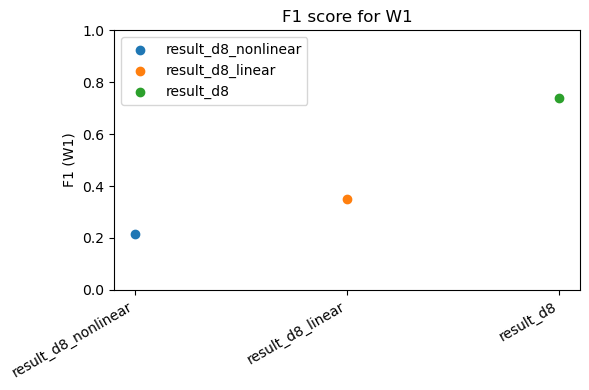

In [8]:
plt.figure(figsize=(6, 4))

for i, name in enumerate(names):
    if "W1" in methods[name]:
        plt.scatter(
            x[i],
            methods[name]["W1"],
            color=colors[name],
            label=name
        )

plt.xticks(x, names, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("F1 (W1)")
plt.title("F1 score for W1")

plt.legend()
plt.tight_layout()
plt.show()



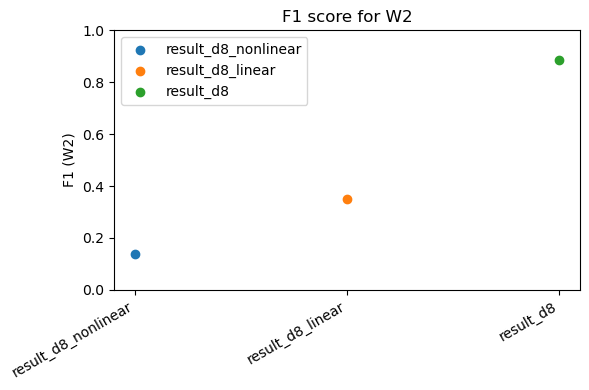

In [9]:
plt.figure(figsize=(6, 4))

for i, name in enumerate(names):
    if "W2" in methods[name]:
        plt.scatter(
            x[i],
            methods[name]["W2"],
            color=colors[name],
            label=name
        )

plt.xticks(x, names, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("F1 (W2)")
plt.title("F1 score for W2")

plt.legend()
plt.tight_layout()
plt.show()

